# Hardware Step 3 — Analyze Results

Load hardware results (unitary and/or dynamic), compare ⟨M_z⟩
against exact simulation, and produce plots.
Runs entirely offline — no IBM account needed.

In [1]:
import sys, os, json, glob
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import exact_trotter_magnetization

## 1. Load hardware results

Loads all result files in `results/hw_data/` and merges them.
This handles the case where unitary and dynamic results were
submitted and retrieved separately.

In [3]:
#HW_DATA_DIR = os.path.join(os.path.dirname(__file__) or ".", "..", "results", "hw_data")
HW_DATA_DIR = os.path.join("..", "results", "hw_data")

result_files = sorted(glob.glob(os.path.join(HW_DATA_DIR, "hw_results_*.json")))
if not result_files:
    print("No hardware results found in results/hw_data/.")
    print("Run 02_retrieve.py first.")
    sys.exit(1)

results = []
for rf in result_files:
    print(f"Loading: {os.path.basename(rf)}")
    with open(rf) as f:
        data = json.load(f)
    results.extend(data)
    print(f"  {len(data)} records ({data[0].get('variant', '?')} from "
          f"{data[0].get('backend', '?')})")

print(f"\nTotal: {len(results)} result records")
variants_found = sorted(set(r["variant"] for r in results))
print(f"Variants: {variants_found}")

Loading: hw_results_dynamic_20260412_194508.json
  5 records (dynamic from ibm_fez)
Loading: hw_results_unitary_20260412_194254.json
  5 records (unitary from ibm_fez)

Total: 10 result records
Variants: ['dynamic', 'unitary']


## 2. Compute exact references and errors

In [4]:
for r in results:
    r["mz_exact"] = exact_trotter_magnetization(
        r["n_qubits"], r["alpha"], 1.0, r["theta"], r["n_steps"],
        cutoff_frac=1e-14,  # full Hamiltonian for exact reference
    )
    r["mz_sim_truncated"] = exact_trotter_magnetization(
        r["n_qubits"], r["alpha"], 1.0, r["theta"], r["n_steps"],
        cutoff_frac=r["cutoff_frac"],  # same truncation as circuit
    )
    r["error_vs_exact"] = abs(r["mz_hardware"] - r["mz_exact"])
    r["error_vs_truncated"] = abs(r["mz_hardware"] - r["mz_sim_truncated"])

# Print summary
print(f"\n{'variant':>10} {'α':>4} | {'Mz_hw':>8} {'Mz_exact':>8} {'err':>7} | "
      f"{'Mz_trunc':>8} {'err_t':>7}")
print("-" * 65)
for r in sorted(results, key=lambda x: (x["variant"], x["alpha"])):
    print(f"{r['variant']:>10} {r['alpha']:>4.1f} | "
          f"{r['mz_hardware']:>+8.4f} {r['mz_exact']:>+8.4f} "
          f"{r['error_vs_exact']:>7.4f} | "
          f"{r['mz_sim_truncated']:>+8.4f} {r['error_vs_truncated']:>7.4f}")


   variant    α |    Mz_hw Mz_exact     err | Mz_trunc   err_t
-----------------------------------------------------------------
   dynamic  0.5 |  +0.4590  +0.7396  0.2806 |  +0.7396  0.2806
   dynamic  1.0 |  +0.4057  +0.6793  0.2737 |  +0.6793  0.2737
   dynamic  2.0 |  +0.3473  +0.5417  0.1944 |  +0.5417  0.1944
   dynamic  4.0 |  +0.3127  +0.4528  0.1400 |  +0.4521  0.1393
   dynamic  8.0 |  +0.3190  +0.4319  0.1129 |  +0.4307  0.1117
   unitary  0.5 |  +0.6511  +0.7396  0.0885 |  +0.7396  0.0885
   unitary  1.0 |  +0.6091  +0.6793  0.0703 |  +0.6793  0.0703
   unitary  2.0 |  +0.4776  +0.5417  0.0641 |  +0.5417  0.0641
   unitary  4.0 |  +0.4496  +0.4528  0.0032 |  +0.4521  0.0025
   unitary  8.0 |  +0.3481  +0.4319  0.0838 |  +0.4307  0.0826


## 3. Plot: hardware vs exact


Plot saved to: ../results/hw_data/hardware_results.png


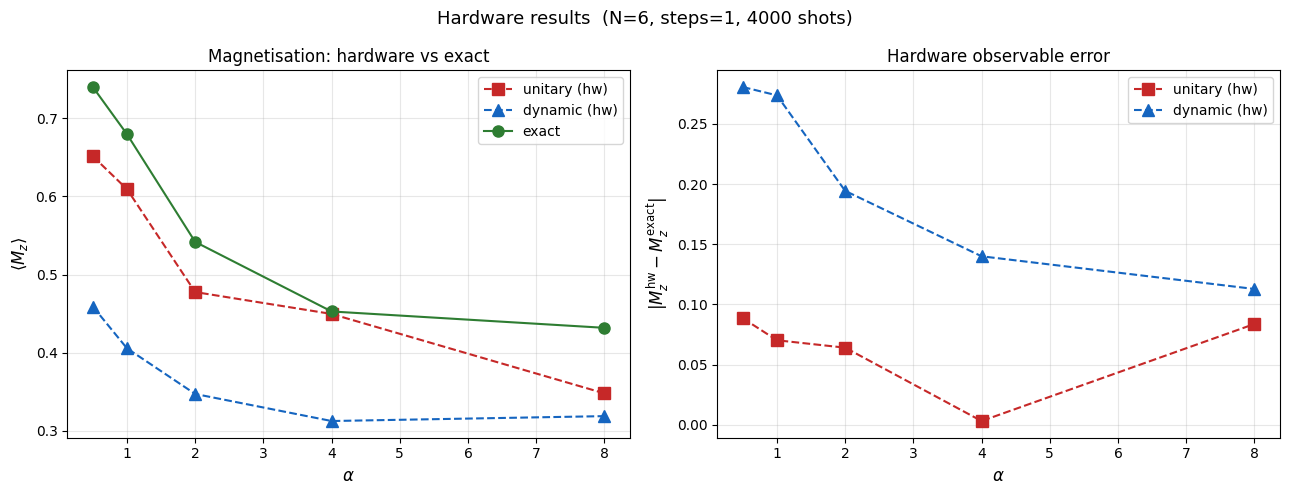

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

variant_styles = {
    "unitary": {"color": "#C62828", "marker": "s", "label": "unitary (hw)"},
    "dynamic": {"color": "#1565C0", "marker": "^", "label": "dynamic (hw)"},
}

# Left panel: M_z values
for variant, style in variant_styles.items():
    sub = sorted([r for r in results if r["variant"] == variant],
                 key=lambda x: x["alpha"])
    if not sub:
        continue
    ax1.plot([r["alpha"] for r in sub], [r["mz_hardware"] for r in sub],
             marker=style["marker"], color=style["color"], ls="--",
             label=style["label"], markersize=8)

# Exact reference
all_alphas = sorted(set(r["alpha"] for r in results))
ref = results[0]
exact_vals = [exact_trotter_magnetization(
    ref["n_qubits"], a, 1.0, ref["theta"], ref["n_steps"], cutoff_frac=1e-14,
) for a in all_alphas]
ax1.plot(all_alphas, exact_vals, "o-", color="#2E7D32", label="exact", markersize=8)

ax1.set_xlabel(r"$\alpha$", fontsize=12)
ax1.set_ylabel(r"$\langle M_z \rangle$", fontsize=12)
ax1.set_title("Magnetisation: hardware vs exact")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right panel: errors
for variant, style in variant_styles.items():
    sub = sorted([r for r in results if r["variant"] == variant],
                 key=lambda x: x["alpha"])
    if not sub:
        continue
    ax2.plot([r["alpha"] for r in sub], [r["error_vs_exact"] for r in sub],
             marker=style["marker"], color=style["color"], ls="--",
             label=style["label"], markersize=8)

ax2.set_xlabel(r"$\alpha$", fontsize=12)
ax2.set_ylabel(r"$|M_z^{\rm hw} - M_z^{\rm exact}|$", fontsize=12)
ax2.set_title("Hardware observable error")
ax2.legend()
ax2.grid(True, alpha=0.3)

n_q = ref["n_qubits"]
n_s = ref["n_steps"]
shots = ref["shots"]
fig.suptitle(f"Hardware results  (N={n_q}, steps={n_s}, {shots} shots)", fontsize=13)
fig.tight_layout()

output_plot = os.path.join(HW_DATA_DIR, "hardware_results.png")
fig.savefig(output_plot, dpi=150)
print(f"\nPlot saved to: {output_plot}")
#plt.show()

## 4. Error breakdown

The total hardware error has two sources:
- **Truncation error**: from dropping weak coupling pairs (cutoff)
- **Hardware noise**: from gate errors, decoherence, readout errors

We can separate these by comparing against both the full-Hamiltonian
exact value and the truncated-Hamiltonian exact value.

In [6]:
print(f"{'variant':>10} {'α':>4} | {'total_err':>9} {'trunc_err':>9} {'hw_noise':>9}")
print("-" * 50)
for r in sorted(results, key=lambda x: (x["variant"], x["alpha"])):
    trunc_err = abs(r["mz_exact"] - r["mz_sim_truncated"])
    hw_noise = r["error_vs_truncated"]
    print(f"{r['variant']:>10} {r['alpha']:>4.1f} | "
          f"{r['error_vs_exact']:>9.4f} {trunc_err:>9.4f} {hw_noise:>9.4f}")

print()
print("total_err  = |Mz_hw - Mz_exact|        (what we ultimately care about)")
print("trunc_err  = |Mz_exact - Mz_truncated|  (from the coupling cutoff)")
print("hw_noise   = |Mz_hw - Mz_truncated|     (from hardware imperfections)")

   variant    α | total_err trunc_err  hw_noise
--------------------------------------------------
   dynamic  0.5 |    0.2806    0.0000    0.2806
   dynamic  1.0 |    0.2737    0.0000    0.2737
   dynamic  2.0 |    0.1944    0.0000    0.1944
   dynamic  4.0 |    0.1400    0.0007    0.1393
   dynamic  8.0 |    0.1129    0.0012    0.1117
   unitary  0.5 |    0.0885    0.0000    0.0885
   unitary  1.0 |    0.0703    0.0000    0.0703
   unitary  2.0 |    0.0641    0.0000    0.0641
   unitary  4.0 |    0.0032    0.0007    0.0025
   unitary  8.0 |    0.0838    0.0012    0.0826

total_err  = |Mz_hw - Mz_exact|        (what we ultimately care about)
trunc_err  = |Mz_exact - Mz_truncated|  (from the coupling cutoff)
hw_noise   = |Mz_hw - Mz_truncated|     (from hardware imperfections)
